In [1]:
import numpy as np
import qutip as qt
from scipy.integrate import quad
from scipy.linalg import det
from scipy.optimize import basinhopping

# plotting setup
import matplotlib.pyplot as plt
plt.style.use('SciencePlots-APS.mplstyle')

## Reduced density matrix

This model based on the paper from Phys. Rev. B 78, 224413 (2008) "Quantum discord and quantum phase transition in spin chains".

In [2]:
#======================================#
# Construct the reduced density matrix
#======================================#
def omega_phi(lam, phi):
    """
    Energy spectrum of the transverse Ising chain.
    """
    omega_val = np.sqrt((lam * np.sin(phi))**2 + (1. + lam*np.cos(phi))**2 )
    return omega_val

def G_k(lam, k):
    """
    Fourier transform of the spin-spin correlation function.
    """
    # Define the integrand functions
    integrand_1 = lambda phi, k, lam: np.cos(phi * k) * (1. + lam * np.cos(phi)) / omega_phi(lam, phi)
    integrand_2 = lambda phi, k, lam: np.sin(phi * k) * np.sin(phi) * lam / omega_phi(lam, phi)
    # Compute the integrals
    integral_1, _ = quad(integrand_1, 0., np.pi, args=(k, lam))
    integral_2, _ = quad(integrand_2, 0., np.pi, args=(k, lam))
    # Calculate the Fourier transform G(k)
    G_k_val = 1. / np.pi * integral_1 - 1. / np.pi * integral_2 
    return G_k_val

# The magnetization of the spin-1/2 Ising chain
def magnetization(lam):
    """
    Compute the magnetization of the spin-1/2 Ising chain.
    """
    # Define the integrand function
    integrand = lambda phi, lam: (1. + lam * np.cos(phi)) / omega_phi(lam, phi)
    # Compute the integral
    integral, _ = quad(integrand, 0., np.pi, args=(lam,))
    # Calculate the magnetization
    magnetization_val = (-1. / np.pi) * integral
    return magnetization_val

#==============================================#
# For the nearest-neighbor correlation function
#==============================================#
# \langle \sigma^{x}_{i} \sigma^{x}_{i+n} \rangle
def correlation_xx(lam):
    return G_k(lam, -1)

# \langle \sigma^{y}_{i} \sigma^{y}_{i+n} \rangle
def correlation_yy(lam):
    return G_k(lam, 1)

# \langle \sigma^{z}_{i} \sigma^{z}_{i+n} \rangle
def correlation_zz(magnetization_val, lam):
    Gk_plus = G_k(lam, 1)
    Gk_minus = G_k(lam, -1)
    return magnetization_val**2 - (Gk_plus * Gk_minus)

#==============================================#
# Reduced density matrix of the Ising chain
#==============================================#
def compute_rho_ij(lam):
    # Compute the magnetization
    magnetization_val = magnetization(lam)
    # Compute the correlation functions
    corr_xx = correlation_xx(lam)
    corr_yy = correlation_yy(lam)
    corr_zz = correlation_zz(magnetization_val, lam)
    # Construct the reduced density matrix
    u_plus = 0.25 + (magnetization_val/2) + (corr_zz/4)
    u_minus = 0.25 - (magnetization_val/2) + (corr_zz/4)
    w = (1.-corr_zz)/4.
    x = (corr_xx + corr_yy)/4.
    y = (corr_xx - corr_yy)/4.

    rho_ij = np.array([
                      [u_plus, 0, 0, y],
                      [0, w, x, 0],
                      [0, x, w, 0],
                      [y, 0, 0, u_minus]
                      ])
    return rho_ij

## Correlation

In [3]:
#################################
# General mathematical functions
#################################
def partial_trace(rho, idx):
    # Find the number of sites in the system
    N = int(np.log2(rho.shape[0]))
    # Convert numpy.ndarray to qutip.Qobj if necessary
    if isinstance(rho, np.ndarray):
        rho = qt.Qobj(rho, dims=[[2]*N]*2)
    # Compute the partial trace
    rho_ptrace = rho.ptrace(idx)
    return rho_ptrace.full()

### Concurrence

In [4]:
#######################
# Concurrence
#######################
def concurrence(rho):
    # Find the number of sites in the system
    N = int(np.log2(rho.shape[0]))
    # Convert numpy.ndarray to qutip.Qobj if necessary
    if isinstance(rho, np.ndarray):
        rho = qt.Qobj(rho, dims=[[2]*N]*2)
    # Compute the spin-flipped state
    rho_tilde = qt.tensor(qt.sigmay(), qt.sigmay()) * rho.conj() * qt.tensor(qt.sigmay(), qt.sigmay())
    # Compute the square root of the matrix
    R = (rho * rho_tilde).sqrtm()
    # Compute the eigenvalues of the matrix R (sorted in descending order)
    eigvals = np.sort(R.eigenenergies())[::-1].real
    # Compute the concurrence
    concurrence = max(0., eigvals[0] - eigvals[1] - eigvals[2] - eigvals[3])
    return concurrence

### Quantum Discord

In [5]:
#######################
# Quantum Discord
#######################
def basis_qd(theta, phi):
    """
    Basis for the quantum discord.
    """
    # Define the basis states
    base_1 = np.cos(theta)*qt.basis(2, 0) + np.exp(1j*phi)*np.sin(theta)*qt.basis(2, 1)
    base_2 = np.exp(-1j*phi)*np.sin(theta)*qt.basis(2, 0) - np.cos(theta)*qt.basis(2, 1)
    return [base_1, base_2]

def entropy_vn(rho):
    """
    Von Neumann entropy of a density matrix.
    """
    
    # Find the number of sites in the system
    N = int(np.log2(rho.shape[0]))
    # Convert numpy.ndarray to qutip.Qobj if necessary
    if isinstance(rho, np.ndarray):
        rho = qt.Qobj(rho, dims=[[2]*N]*2)
    # Compute the Von Neumann entropy
    entropy = qt.entropy_vn(rho)
    return entropy

def entropy_conditional(rho_AB, base_b):
    # Find the number of sites in the system
    N = int(np.log2(rho_AB.shape[0]))
    # Convert numpy.ndarray to qutip.Qobj if necessary
    if isinstance(rho_AB, np.ndarray):
        rho_AB = qt.Qobj(rho_AB, dims=[[2]*N]*2)
    # Compute the conditional entropy
    entropy = 0.0
    for i in range(len(base_b)):
        # Projector onto the basis state base_b[i]
        proj_b = base_b[i] * base_b[i].dag()
        # Tensor product with identity to form the measurement operator
        Pi = qt.tensor(qt.qeye(2), proj_b)
        # Probability of measurement outcome
        pj = np.real((qt.tensor(qt.qeye(2), proj_b) * rho_AB).tr() )
        if pj < 1e-12:
            pj = 1e-12
        # Conditional entropy
        rho_A_phi = (Pi * rho_AB * Pi)/ pj
        entropy += pj * qt.entropy_vn(rho_A_phi)
    return entropy

def quantum_discord(rho_AB):
    # Find the number of sites in the system
    N = int(np.log2(rho_AB.shape[0]))
    # Convert numpy.ndarray to qutip.Qobj if necessary
    if isinstance(rho_AB, np.ndarray):
        rho_AB = qt.Qobj(rho_AB, dims=[[2]*N]*2)
    
    def obj_func(params):
        theta, phi = params
        base_b = basis_qd(theta, phi)
        # von Neumann entropy of the rho_AB
        H_AB = entropy_vn(rho_AB)
        # von Neumann entropy of the reduced rho_A
        H_A = entropy_vn(partial_trace(rho_AB, 1))
        # Conditional entropy
        H_A_B = entropy_conditional(rho_AB, base_b)
        # Quantum discord
        discord = H_A - H_AB + H_A_B
        return float(discord)  # Ensure the return value is a scalar
    
    # Bounds for the optimization
    bounds = [(0, np.pi), (0, 2*np.pi)]
    # Initial guess
    init_guess = np.array([np.pi/2, 0])
    
    # Perform the optimization to find the minimum of the objective function (quantum discord)
    minimizer_kwargs = {"method": "L-BFGS-B", "bounds": bounds}
    res = basinhopping(obj_func, init_guess, minimizer_kwargs=minimizer_kwargs, niter=20)
    return res.fun  

## Main calculation

In [6]:
lambda_vals = np.linspace(0., 2., 100, endpoint=True)

# Compute concurrence 
concurrence_vals = np.zeros_like(lambda_vals)
for i in range(len(lambda_vals)):
    rho_ij = compute_rho_ij(lambda_vals[i])
    concurrence_vals[i] = concurrence(rho_ij)

# Compute quantum discord
discord_vals = np.zeros_like(lambda_vals)
for i in range(len(lambda_vals)):
    rho_ij = compute_rho_ij(lambda_vals[i])
    discord_vals[i] = quantum_discord(rho_ij)

# KD correlation
lamb_, KD_corr_vals = np.loadtxt('./KD_correlation.dat', unpack=True)

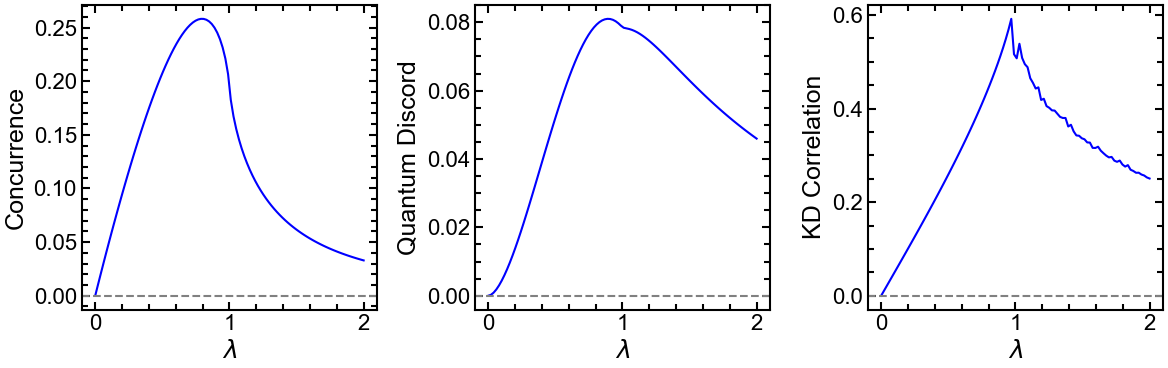

In [7]:
# Plot correlation with 1x3 subplots for concurrence, quantum discord and KD correlation
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Plot concurrence
axs[0].plot(lambda_vals, concurrence_vals, 'b-', label='Concurrence')
axs[0].set_xlabel(r'$\lambda$')
axs[0].set_ylabel(r'Concurrence')
axs[0].axhline(y=0.0, color='gray', linestyle='--')

# Plot quantum discord
axs[1].plot(lambda_vals, discord_vals, 'b-', label='Quantum Discord')
axs[1].set_xlabel(r'$\lambda$')
axs[1].set_ylabel(r'Quantum Discord')
axs[1].axhline(y=0.0, color='gray', linestyle='--')

# Plot KD correlation
axs[2].plot(lamb_, KD_corr_vals, 'b-', label='KD Correlation')
axs[2].set_xlabel(r'$\lambda$')
axs[2].set_ylabel(r'KD Correlation')
axs[2].axhline(y=0.0, color='gray', linestyle='--')

plt.tight_layout()
plt.show()